<a href="https://colab.research.google.com/github/shreecodes11/motion-blur-object-detection-benchmark/blob/main/BenchMarking_MotionBlur_Robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics
!pip install opencv-python
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.6 MB/s eta 0:00:00


In [2]:
!pip install -q datasets

In [3]:
from datasets import load_dataset
import os

os.makedirs("images", exist_ok=True)


dataset = load_dataset("detection-datasets/coco", split="val")

print("Total samples:", len(dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

data/train-00000-of-00040-67e35002d15215(…):   0%|          | 0.00/485M [00:00<?, ?B/s]

...

data/val-00000-of-00002-c4f2e391ee4aba11(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

data/val-00001-of-00002-7af5414a3b178949(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117266 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4952 [00:00<?, ? examples/s]

Total samples: 4952


In [4]:
import random

num_images = 100
indices = random.sample(range(len(dataset)), num_images)

os.makedirs("images", exist_ok=True)

for i, idx in enumerate(indices):
    img = dataset[idx]["image"]
    img.save(f"images/img_{i}.jpg")

print("Saved images:", num_images)

Saved images: 100


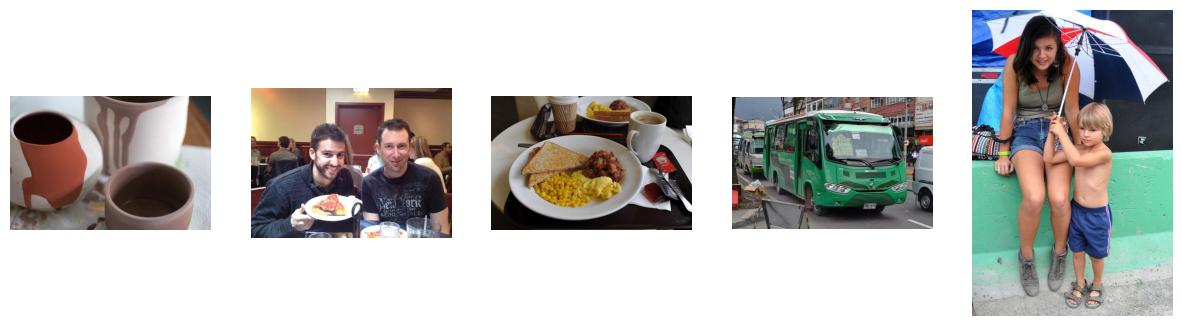

In [5]:
import os
import cv2
import matplotlib.pyplot as plt

image_files = os.listdir("images")[:5]

plt.figure(figsize=(15,5))

for i, img_file in enumerate(image_files):
    img = cv2.imread(os.path.join("images", img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [6]:
import cv2
import numpy as np

def motion_blur(image, kernel_size=15, angle=0):

    kernel = np.zeros((kernel_size, kernel_size))

    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)

    center = (kernel_size/2 - 0.5, kernel_size/2 - 0.5)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1)

    kernel = cv2.warpAffine(
        kernel,
        rotation_matrix,
        (kernel_size, kernel_size)
    )

    kernel = kernel / np.sum(kernel)

    blurred = cv2.filter2D(image, -1, kernel)

    return blurred

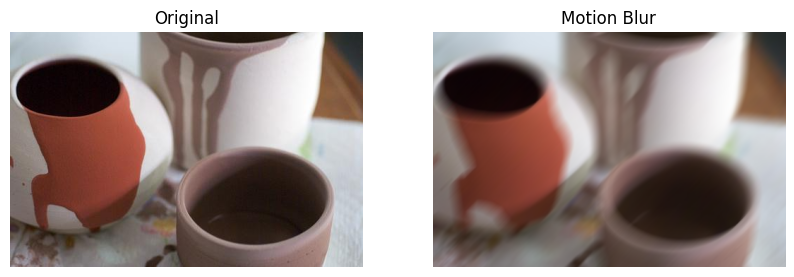

In [7]:
img_path = os.path.join("images", image_files[0])

img = cv2.imread(img_path)

blurred = motion_blur(
    img,
    kernel_size=25,
    angle=45
)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
blur_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur_rgb)
plt.title("Motion Blur")
plt.axis("off")

plt.show()

In [8]:
import os
import cv2
import random

os.makedirs("blurred_images", exist_ok=True)

image_files = os.listdir("images")

for img_file in image_files:

    img_path = os.path.join("images", img_file)

    img = cv2.imread(img_path)

    # Random blur settings
    kernel_size = random.choice([15, 25, 45])
    angle = random.randint(0, 180)

    blurred = motion_blur(
        img,
        kernel_size=kernel_size,
        angle=angle
    )

    save_path = os.path.join(
        "blurred_images",
        img_file
    )

    cv2.imwrite(save_path, blurred)

print("Blurred images created:", len(os.listdir("blurred_images")))

Blurred images created: 100


In [9]:
len(os.listdir("images"))

100

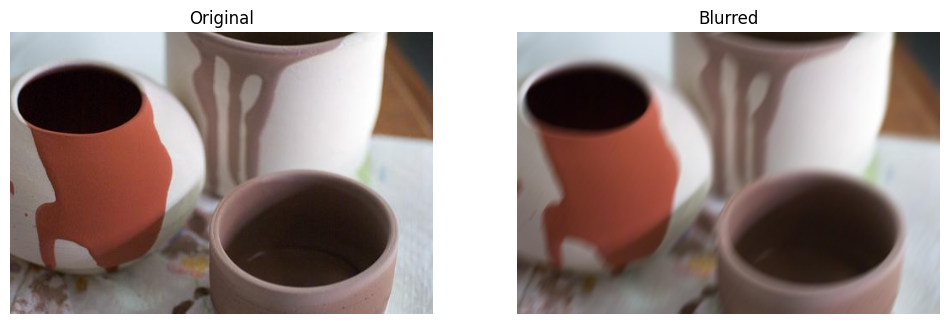

In [10]:
import matplotlib.pyplot as plt

sample = image_files[0]

orig = cv2.imread(
    os.path.join("images", sample)
)

blur = cv2.imread(
    os.path.join("blurred_images", sample)
)

orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
blur = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur)
plt.title("Blurred")
plt.axis("off")

plt.show()

In [11]:
!pip install ultralytics

In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n loaded successfully!



image 1/1 /content/images/img_92.jpg: 448x640 2 cups, 75.1ms
Speed: 12.3ms preprocess, 75.1ms inference, 63.1ms postprocess per image at shape (1, 3, 448, 640)


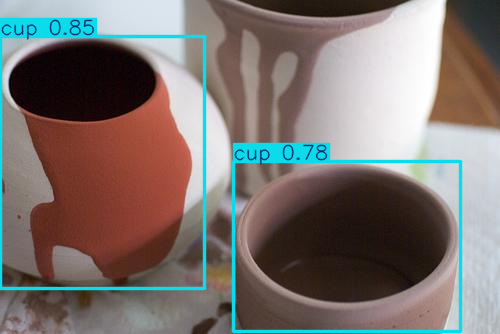

In [13]:
import os

sample_image = os.path.join(
    "images",
    os.listdir("images")[0]
)

results = model(sample_image)

results[0].show()


image 1/1 /content/blurred_images/img_92.jpg: 448x640 2 cups, 12.4ms
Speed: 8.0ms preprocess, 12.4ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


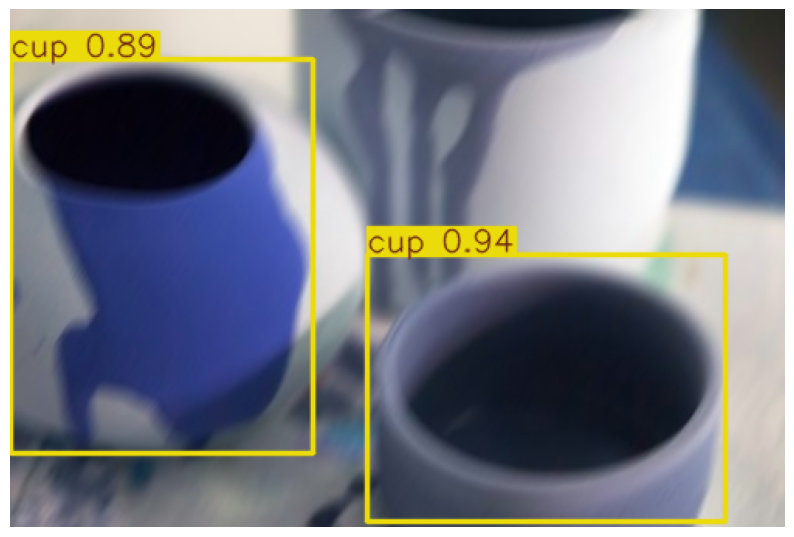

In [14]:
sample_name = os.listdir("images")[0]

blurred_path = os.path.join(
    "blurred_images",
    sample_name
)

results_blur = model(blurred_path)

annotated_blur = results_blur[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated_blur)
plt.axis("off")
plt.show()

In [15]:
results_blur = model(blurred_path)

print("Number of detections:", len(results_blur[0].boxes))


image 1/1 /content/blurred_images/img_92.jpg: 448x640 2 cups, 16.0ms
Speed: 5.2ms preprocess, 16.0ms inference, 4.0ms postprocess per image at shape (1, 3, 448, 640)
Number of detections: 2


In [16]:
import random
import os

for _ in range(3):
    img_name = random.choice(os.listdir("blurred_images"))
    result = model(os.path.join("blurred_images", img_name))
    print(img_name, "->", len(result[0].boxes))


image 1/1 /content/blurred_images/img_92.jpg: 448x640 2 cups, 12.7ms
Speed: 3.3ms preprocess, 12.7ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)
img_92.jpg -> 2

image 1/1 /content/blurred_images/img_98.jpg: 448x640 1 person, 15.5ms
Speed: 4.1ms preprocess, 15.5ms inference, 4.7ms postprocess per image at shape (1, 3, 448, 640)
img_98.jpg -> 1

image 1/1 /content/blurred_images/img_52.jpg: 448x640 1 person, 18.3ms
Speed: 3.4ms preprocess, 18.3ms inference, 4.1ms postprocess per image at shape (1, 3, 448, 640)
img_52.jpg -> 1


In [17]:
import os
import pandas as pd

results_data = []

image_files = os.listdir("images")

for img_file in image_files:

    img_path = os.path.join("images", img_file)

    results = model(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(results[0].boxes.conf.mean())
    else:
        avg_conf = 0

    results_data.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_original = pd.DataFrame(
    results_data,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_original.head())


image 1/1 /content/images/img_92.jpg: 448x640 2 cups, 10.9ms
Speed: 3.5ms preprocess, 10.9ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_35.jpg: 480x640 8 persons, 1 wine glass, 4 cups, 2 pizzas, 4 chairs, 1 dining table, 78.1ms
Speed: 4.5ms preprocess, 78.1ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/images/img_28.jpg: 448x640 2 cups, 1 bowl, 1 sandwich, 1 dining table, 14.7ms
Speed: 2.9ms preprocess, 14.7ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_50.jpg: 448x640 1 person, 2 buss, 1 truck, 11.0ms
Speed: 3.1ms preprocess, 11.0ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_87.jpg: 640x448 2 persons, 1 umbrella, 69.6ms
Speed: 2.8ms preprocess, 69.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/images/img_68.jpg: 480x640 2 persons, 13 cows, 10.7ms


In [18]:
print("Average detections:",
      df_original["detections"].mean())

print("Average confidence:",
      df_original["avg_confidence"].mean())

Average detections: 5.04
Average confidence: 0.632013555765152


In [19]:
results_blur = []

blur_files = os.listdir("blurred_images")

for img_file in blur_files:

    img_path = os.path.join(
        "blurred_images",
        img_file
    )

    results = model(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(
            results[0].boxes.conf.mean()
        )
    else:
        avg_conf = 0

    results_blur.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_blur = pd.DataFrame(
    results_blur,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_blur.head())


image 1/1 /content/blurred_images/img_92.jpg: 448x640 2 cups, 13.5ms
Speed: 3.0ms preprocess, 13.5ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_35.jpg: 480x640 3 persons, 14.1ms
Speed: 2.0ms preprocess, 14.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/blurred_images/img_28.jpg: 448x640 2 cups, 1 knife, 1 bowl, 1 cake, 1 dining table, 17.7ms
Speed: 1.9ms preprocess, 17.7ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_50.jpg: 448x640 1 car, 1 bus, 1 truck, 15.4ms
Speed: 4.4ms preprocess, 15.4ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_87.jpg: 640x448 2 persons, 1 umbrella, 1 tennis racket, 25.1ms
Speed: 3.9ms preprocess, 25.1ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/blurred_images/img_68.jpg: 480x640 1 bird, 1 cow, 13.2

In [20]:
print("Average detections:",
      df_blur["detections"].mean())

print("Average confidence:",
      df_blur["avg_confidence"].mean())

Average detections: 1.44
Average confidence: 0.37215020537376403


In [21]:
from ultralytics import YOLO

model_s = YOLO("yolov8s.pt")

print("YOLOv8s loaded successfully!")

YOLOv8s loaded successfully!


In [22]:
import os
import pandas as pd

results_s_original = []

for img_file in os.listdir("images"):

    img_path = os.path.join(
        "images",
        img_file
    )

    results = model_s(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(
            results[0].boxes.conf.mean()
        )
    else:
        avg_conf = 0

    results_s_original.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_s_original = pd.DataFrame(
    results_s_original,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_s_original.head())


image 1/1 /content/images/img_92.jpg: 448x640 3 cups, 1 bowl, 69.8ms
Speed: 2.7ms preprocess, 69.8ms inference, 3.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_35.jpg: 480x640 7 persons, 4 cups, 1 pizza, 5 chairs, 2 dining tables, 97.1ms
Speed: 2.0ms preprocess, 97.1ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/images/img_28.jpg: 448x640 2 cups, 1 fork, 1 sandwich, 1 dining table, 18.3ms
Speed: 2.2ms preprocess, 18.3ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_50.jpg: 448x640 2 persons, 1 car, 3 buss, 1 truck, 13.1ms
Speed: 2.2ms preprocess, 13.1ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/images/img_87.jpg: 640x448 2 persons, 2 umbrellas, 1 handbag, 64.3ms
Speed: 2.0ms preprocess, 64.3ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/images/img_68.jpg: 480x640 2 persons, 9 

In [23]:
print(
    "Average detections:",
    df_s_original["detections"].mean()
)

print(
    "Average confidence:",
    df_s_original["avg_confidence"].mean()
)

Average detections: 6.0
Average confidence: 0.6639460441470146


In [24]:
results_s_blur = []

for img_file in os.listdir("blurred_images"):

    img_path = os.path.join(
        "blurred_images",
        img_file
    )

    results = model_s(img_path)

    num_detections = len(results[0].boxes)

    if num_detections > 0:
        avg_conf = float(
            results[0].boxes.conf.mean()
        )
    else:
        avg_conf = 0

    results_s_blur.append([
        img_file,
        num_detections,
        avg_conf
    ])

df_s_blur = pd.DataFrame(
    results_s_blur,
    columns=[
        "image",
        "detections",
        "avg_confidence"
    ]
)

print(df_s_blur.head())


image 1/1 /content/blurred_images/img_92.jpg: 448x640 2 cups, 1 vase, 32.2ms
Speed: 7.0ms preprocess, 32.2ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_35.jpg: 480x640 4 persons, 14.4ms
Speed: 2.9ms preprocess, 14.4ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/blurred_images/img_28.jpg: 448x640 2 cups, 1 fork, 1 bowl, 1 cake, 1 dining table, 30.0ms
Speed: 1.8ms preprocess, 30.0ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_50.jpg: 448x640 1 car, 1 bus, 1 truck, 37.7ms
Speed: 1.8ms preprocess, 37.7ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/blurred_images/img_87.jpg: 640x448 2 persons, 1 umbrella, 1 skateboard, 1 tennis racket, 36.0ms
Speed: 6.9ms preprocess, 36.0ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/blurred_images/img_68.jpg: 480x64

In [25]:
print(
    "Average detections:",
    df_s_blur["detections"].mean()
)

print(
    "Average confidence:",
    df_s_blur["avg_confidence"].mean()
)

Average detections: 1.81
Average confidence: 0.415748299062252


In [26]:
from ultralytics import RTDETR

rtdetr_model = RTDETR("rtdetr-l.pt")

print("RT-DETR loaded successfully!")

RT-DETR loaded successfully!


In [27]:
import random
import os

test_img = random.choice(os.listdir("images"))

result = rtdetr_model(os.path.join("images", test_img))

print("Detections:", len(result[0].boxes))


image 1/1 /content/images/img_16.jpg: 640x640 4 zebras, 107.3ms
Speed: 9.3ms preprocess, 107.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Detections: 4


In [28]:
import os
import pandas as pd

results_original_rtdetr = []

for img_name in os.listdir("images"):
    img_path = os.path.join("images", img_name)

    result = rtdetr_model(img_path)

    detections = len(result[0].boxes)

    if detections > 0:
        avg_conf = float(result[0].boxes.conf.mean())
    else:
        avg_conf = 0

    results_original_rtdetr.append(
        [img_name, detections, avg_conf]
    )

df_rtdetr_original = pd.DataFrame(
    results_original_rtdetr,
    columns=["image", "detections", "avg_confidence"]
)

df_rtdetr_original.head()


image 1/1 /content/images/img_92.jpg: 640x640 3 cups, 3 bowls, 1 dining table, 4 vases, 100.8ms
Speed: 13.1ms preprocess, 100.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_35.jpg: 640x640 10 persons, 1 bottle, 6 cups, 2 pizzas, 10 chairs, 5 dining tables, 101.7ms
Speed: 4.6ms preprocess, 101.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_28.jpg: 640x640 2 cups, 2 forks, 6 knifes, 2 spoons, 3 bowls, 2 sandwichs, 2 dining tables, 1 cell phone, 117.2ms
Speed: 3.6ms preprocess, 117.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_50.jpg: 640x640 3 persons, 5 cars, 4 buss, 4 trucks, 1 stop sign, 1 suitcase, 1 chair, 95.0ms
Speed: 3.8ms preprocess, 95.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/images/img_87.jpg: 640x640 2 persons, 1 umbrella, 2 handbags, 95.2ms
Speed: 5.2ms preprocess, 95.2

,image,detections,avg_confidence
0,img_92.jpg,11,0.437054
1,img_35.jpg,34,0.541404
2,img_28.jpg,20,0.480816
3,img_50.jpg,19,0.453810
4,img_87.jpg,5,0.768579


In [29]:
print(
    "Average detections:",
    df_rtdetr_original["detections"].mean()
)

print(
    "Average confidence:",
    df_rtdetr_original["avg_confidence"].mean()
)

Average detections: 13.38
Average confidence: 0.6238190498948097


In [30]:
results_blur_rtdetr = []

for img_name in os.listdir("blurred_images"):
    img_path = os.path.join("blurred_images", img_name)

    result = rtdetr_model(img_path)

    detections = len(result[0].boxes)

    if detections > 0:
        avg_conf = float(result[0].boxes.conf.mean())
    else:
        avg_conf = 0

    results_blur_rtdetr.append(
        [img_name, detections, avg_conf]
    )

df_rtdetr_blur = pd.DataFrame(
    results_blur_rtdetr,
    columns=["image", "detections", "avg_confidence"]
)

df_rtdetr_blur.head()


image 1/1 /content/blurred_images/img_92.jpg: 640x640 3 cups, 2 bowls, 1 dining table, 1 vase, 99.6ms
Speed: 3.6ms preprocess, 99.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_35.jpg: 640x640 11 persons, 1 cup, 2 pizzas, 1 dining table, 115.1ms
Speed: 3.4ms preprocess, 115.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_28.jpg: 640x640 2 cups, 4 forks, 2 knifes, 5 spoons, 2 bowls, 1 sandwich, 1 dining table, 175.3ms
Speed: 7.5ms preprocess, 175.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_50.jpg: 640x640 1 car, 2 buss, 3 trucks, 139.6ms
Speed: 3.4ms preprocess, 139.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/blurred_images/img_87.jpg: 640x640 2 persons, 4 umbrellas, 1 handbag, 121.1ms
Speed: 4.2ms preprocess, 121.1ms inference, 3.2ms postprocess per image at 

,image,detections,avg_confidence
0,img_92.jpg,7,0.533595
1,img_35.jpg,15,0.497551
2,img_28.jpg,17,0.449102
3,img_50.jpg,6,0.502610
4,img_87.jpg,7,0.549820


In [31]:
print(
    "Average detections:",
    df_rtdetr_blur["detections"].mean()
)

print(
    "Average confidence:",
    df_rtdetr_blur["avg_confidence"].mean()
)

Average detections: 6.92
Average confidence: 0.49105580389499665


In [32]:
import random
import os

# Choose a random image from the original images directory
fixed_img = random.choice(os.listdir("/content/images"))

print("Selected image:", fixed_img)

Selected image: img_20.jpg



image 1/1 /content/blurred_images/img_20.jpg: 480x640 1 person, 8.3ms
Speed: 1.6ms preprocess, 8.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


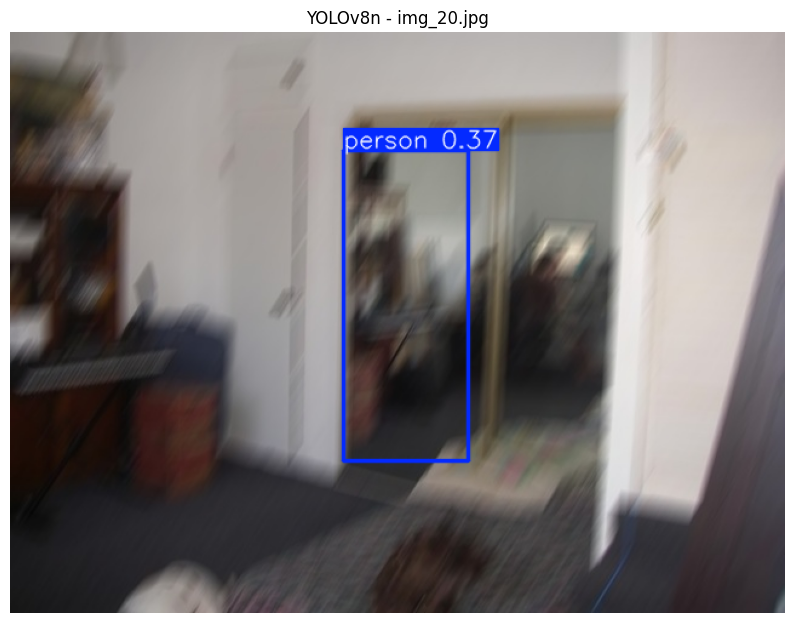

In [33]:
import os
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

result = model(img_path)

annotated = result[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.title(f"YOLOv8n - {fixed_img}")
plt.show()


image 1/1 /content/blurred_images/img_20.jpg: 480x640 1 person, 12.9ms
Speed: 2.0ms preprocess, 12.9ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


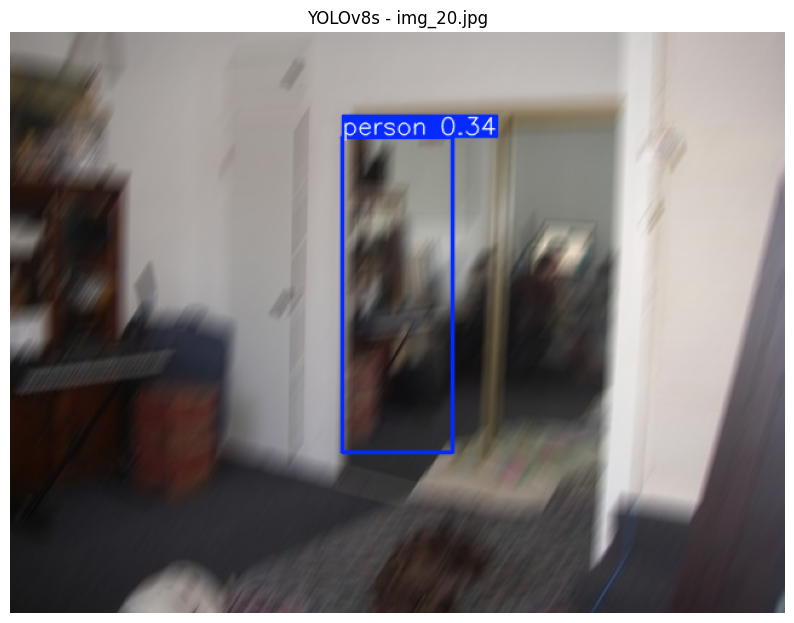

In [34]:
import os
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

result = model_s(img_path)

annotated = result[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.title(f"YOLOv8s - {fixed_img}")
plt.show()


image 1/1 /content/blurred_images/img_20.jpg: 640x640 1 person, 2 cars, 2 suitcases, 62.4ms
Speed: 4.3ms preprocess, 62.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


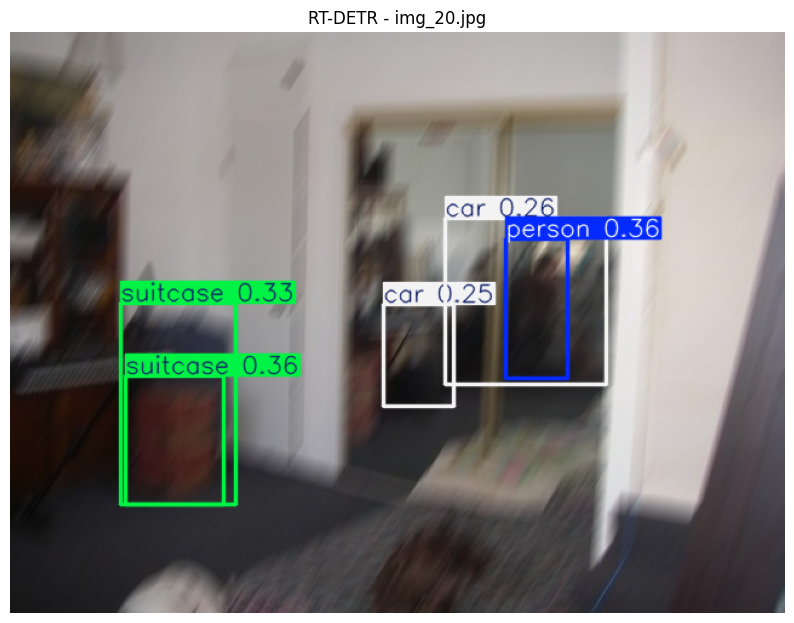

In [35]:
import os
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

result = rtdetr_model(img_path)

annotated = result[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated[:,:,::-1])
plt.axis("off")
plt.title(f"RT-DETR - {fixed_img}")
plt.show()

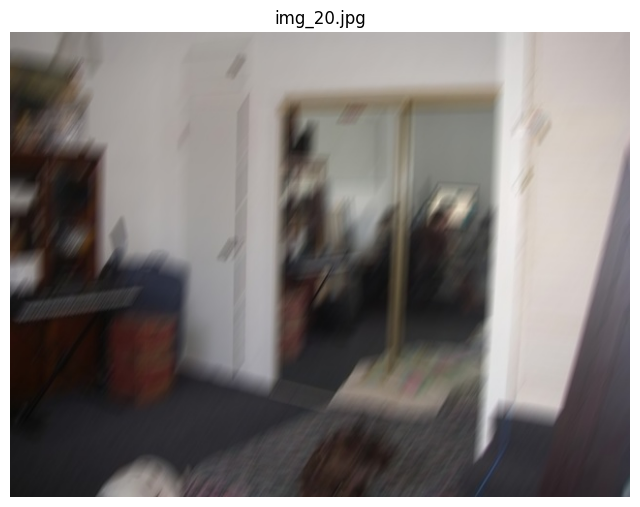

In [36]:
import os
import cv2
import matplotlib.pyplot as plt

img_path = os.path.join("blurred_images", fixed_img)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title(fixed_img)
plt.show()

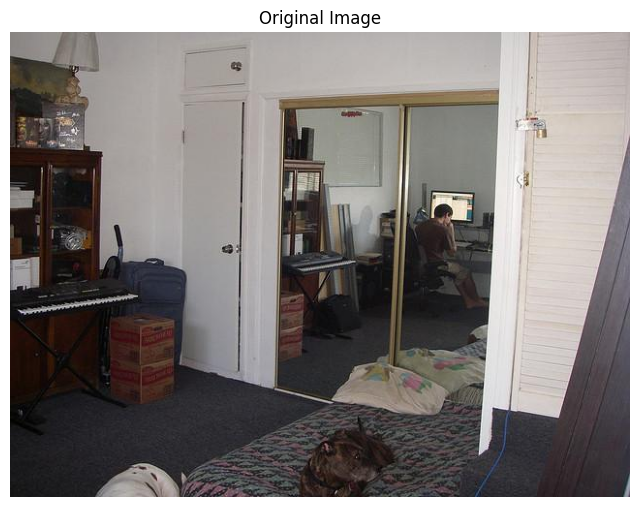

In [37]:
original_path = os.path.join("images", fixed_img)

img = cv2.imread(original_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [38]:
!pip install -q transformers
!pip install -q timm
!pip install -q pillow

In [39]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

gnd_processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
gnd_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    "IDEA-Research/grounding-dino-base"
).to(device)

print("GroundingDINO loaded!")

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

GroundingDINO loaded!


In [40]:
import os
print(os.getcwd())

/content


In [41]:
!ls /content

blurred_images	images	rtdetr-l.pt  sample_data  yolov8n.pt  yolov8s.pt


In [42]:
print(os.listdir("/content/images")[:5])

['img_92.jpg', 'img_35.jpg', 'img_28.jpg', 'img_50.jpg', 'img_87.jpg']


In [43]:
import transformers
print(transformers.__version__)

5.10.1


In [46]:
import inspect

print(inspect.signature(gnd_processor.post_process_grounded_object_detection))

(outputs: 'GroundingDinoObjectDetectionOutput', input_ids: transformers.utils.generic.TensorType | None = None, threshold: float = 0.25, text_threshold: float = 0.25, target_sizes: transformers.utils.generic.TensorType | list[tuple] | None = None, text_labels: list[list[str]] | None = None)


In [48]:
from PIL import Image
import os
import torch

img_path = "/content/images/" + os.listdir("/content/images")[0]

image = Image.open(img_path).convert("RGB")

inputs = gnd_processor(
    images=image,
    text="person. car. bicycle. dog. cat. umbrella.",
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = gnd_model(**inputs)

results = gnd_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.3,
    text_threshold=0.25,
    target_sizes=[image.size[::-1]]
)

print("Detections:", len(results[0]["boxes"]))

Detections: 0


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


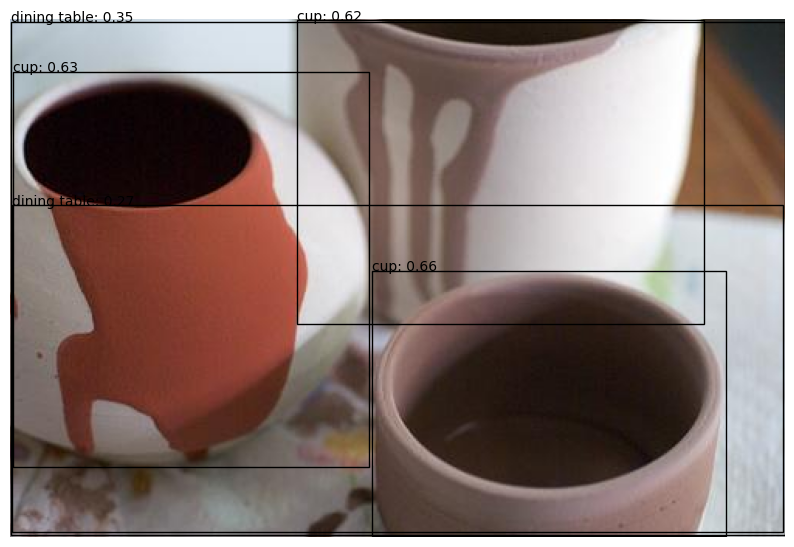

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

img_path = "/content/images/" + os.listdir("/content/images")[0]

image = Image.open(img_path).convert("RGB")

inputs = gnd_processor(
    images=image,
    text = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
""",
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = gnd_model(**inputs)

results = gnd_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.25,
    text_threshold=0.25,
    target_sizes=[image.size[::-1]]
)

boxes = results[0]["boxes"]
scores = results[0]["scores"]
labels = results[0]["labels"]

fig, ax = plt.subplots(figsize=(10,8))
ax.imshow(image)

for box, score, label in zip(boxes, scores, labels):
    x1, y1, x2, y2 = box.tolist()

    rect = patches.Rectangle(
        (x1,
        y1),
        x2-x1,
        y2-y1,
        fill=False
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        f"{label}: {score:.2f}"
    )

plt.axis("off")
plt.show()

In [52]:
import pandas as pd
import os
from PIL import Image
import torch

TEXT_PROMPT = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
"""

image_folder = "/content/images"

orig_results = []

for img_name in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_name)
    image = Image.open(img_path).convert("RGB")

    inputs = gnd_processor(
        images=image,
        text=TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = gnd_model(**inputs)

    results = gnd_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        text_threshold=0.3,
        target_sizes=[image.size[::-1]]
    )

    scores = results[0]["scores"]

    det_count = (scores > 0.3).sum().item()
    avg_conf = scores.mean().item() if len(scores) > 0 else 0

    orig_results.append({
        "image": img_name,
        "detections": det_count,
        "avg_confidence": avg_conf
    })

df_orig = pd.DataFrame(orig_results)

print("GroundingDINO - Original")
print("Avg detections:", df_orig["detections"].mean())
print("Avg confidence:", df_orig["avg_confidence"].mean())

df_orig.head()

GroundingDINO - Original
Avg detections: 5.91
Avg confidence: 0.5351636216044426


,image,detections,avg_confidence
0,img_92.jpg,4,0.566788
1,img_35.jpg,29,0.466818
2,img_28.jpg,5,0.446126
3,img_50.jpg,11,0.443749
4,img_87.jpg,5,0.507745


In [54]:
import pandas as pd
import os
from PIL import Image
import torch

TEXT_PROMPT = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
"""

image_folder = "/content/blurred_images"

blur_results = []

for img_name in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_name)
    image = Image.open(img_path).convert("RGB")

    inputs = gnd_processor(
        images=image,
        text=TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = gnd_model(**inputs)

    results = gnd_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        text_threshold=0.3,
        target_sizes=[image.size[::-1]]
    )

    scores = results[0]["scores"]

    det_count = (scores > 0.3).sum().item()
    avg_conf = scores.mean().item() if len(scores) > 0 else 0

    blur_results.append({
        "image": img_name,
        "detections": det_count,
        "avg_confidence": avg_conf
    })

df_blur = pd.DataFrame(blur_results)

print("GroundingDINO - Blurred")
print("Avg detections:", df_blur["detections"].mean())
print("Avg confidence:", df_blur["avg_confidence"].mean())

df_blur.head()

GroundingDINO - Blurred
Avg detections: 2.5
Avg confidence: 0.4980148008465767


,image,detections,avg_confidence
0,img_92.jpg,5,0.504956
1,img_35.jpg,10,0.476209
2,img_28.jpg,5,0.479695
3,img_50.jpg,4,0.512917
4,img_87.jpg,3,0.731587


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


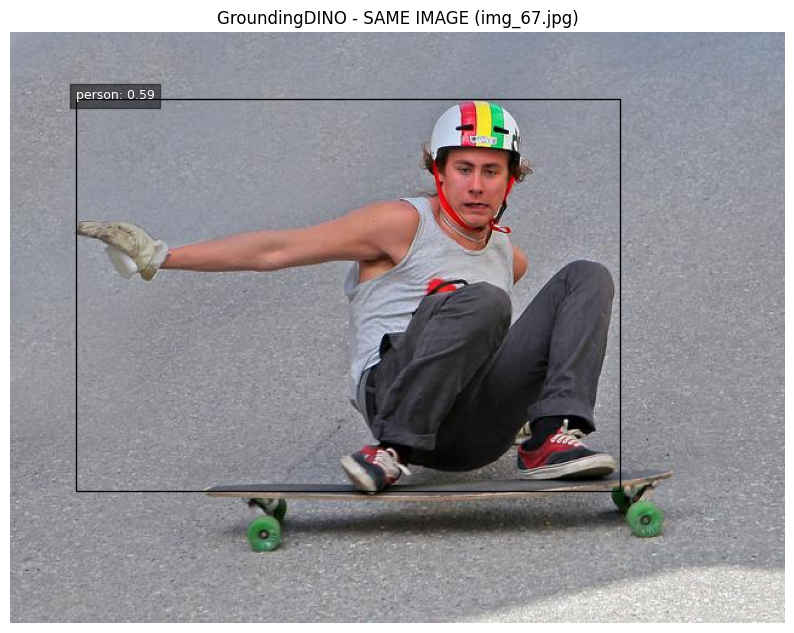

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

TEXT_PROMPT = """
person. bicycle. car. motorcycle. airplane. bus. train.
truck. boat. traffic light. fire hydrant. stop sign.
bench. bird. cat. dog. horse. sheep. cow.
elephant. bear. zebra. giraffe. backpack. umbrella.
handbag. suitcase. bottle. cup. chair. couch.
potted plant. bed. dining table. laptop. mouse.
keyboard. cell phone. book.
"""

# SAME IMAGE USED FOR ALL MODELS
fixed_img = "img_67.jpg"
img_path = "/content/images/" + fixed_img

image = Image.open(img_path).convert("RGB")

# Inference
inputs = gnd_processor(
    images=image,
    text=TEXT_PROMPT,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = gnd_model(**inputs)

# Post-process
results = gnd_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.3,
    text_threshold=0.3,
    target_sizes=[image.size[::-1]]
)

boxes = results[0]["boxes"]
scores = results[0]["scores"]
labels = results[0]["labels"]

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image)

for box, score, label in zip(boxes, scores, labels):
    if score < 0.3:
        continue

    x1, y1, x2, y2 = box.tolist()

    rect = patches.Rectangle(
        (x1,
        y1),
        x2 - x1,
        y2 - y1,
        fill=False
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        f"{label}: {score:.2f}",
        fontsize=9,
        color="white",
        bbox=dict(facecolor="black", alpha=0.5)
    )

plt.axis("off")
plt.title("GroundingDINO - SAME IMAGE (img_67.jpg)")
plt.show()

In [57]:
print("Scores:", results[0]["scores"])
print("Max score:", results[0]["scores"].max() if len(results[0]["scores"]) > 0 else 0)
print("Num raw boxes:", len(results[0]["boxes"]))

Scores: tensor([0.5855], device='cuda:0')
Max score: tensor(0.5855, device='cuda:0')
Num raw boxes: 1


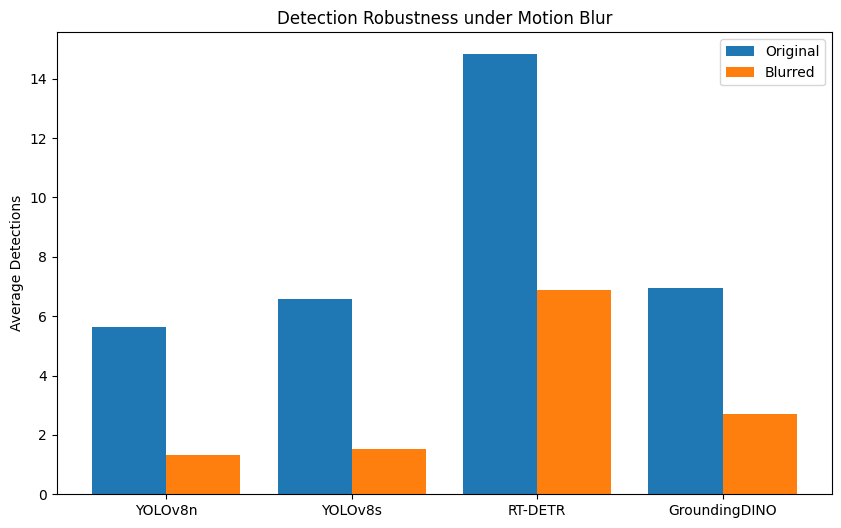

In [58]:
import matplotlib.pyplot as plt

models = ["YOLOv8n", "YOLOv8s", "RT-DETR", "GroundingDINO"]

orig = [5.65, 6.58, 14.82, 6.94]
blur = [1.31, 1.51, 6.87, 2.71]

x = range(len(models))

plt.figure(figsize=(10,6))
plt.bar(x, orig, width=0.4, label="Original")
plt.bar([i + 0.4 for i in x], blur, width=0.4, label="Blurred")

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("Average Detections")
plt.title("Detection Robustness under Motion Blur")
plt.legend()
plt.show()

In [59]:
yolov8n_avg_detections_orig = df_original["detections"].mean()
yolov8n_avg_confidence_orig = df_original["avg_confidence"].mean()

yolov8n_avg_detections_blur = df_blur["detections"].mean()
yolov8n_avg_confidence_blur = df_blur["avg_confidence"].mean()

yolov8s_avg_detections_orig = df_s_original["detections"].mean()
yolov8s_avg_confidence_orig = df_s_original["avg_confidence"].mean()

yolov8s_avg_detections_blur = df_s_blur["detections"].mean()
yolov8s_avg_confidence_blur = df_s_blur["avg_confidence"].mean()

rtdetr_avg_detections_orig = df_rtdetr_original["detections"].mean()
rtdetr_avg_confidence_orig = df_rtdetr_original["avg_confidence"].mean()

rtdetr_avg_detections_blur = df_rtdetr_blur["detections"].mean()
rtdetr_avg_confidence_blur = df_rtdetr_blur["avg_confidence"].mean()

gdino_avg_detections_orig = df_orig["detections"].mean()
gdino_avg_confidence_orig = df_orig["avg_confidence"].mean()

gdino_avg_detections_blur = df_blur["detections"].mean()
gdino_avg_confidence_blur = df_blur["avg_confidence"].mean()


comparison_data = {
    'Model': ['YOLOv8n', 'YOLOv8s', 'RT-DETR', 'GroundingDINO'],
    'Original Avg Detections': [
        yolov8n_avg_detections_orig,
        yolov8s_avg_detections_orig,
        rtdetr_avg_detections_orig,
        gdino_avg_detections_orig
    ],
    'Original Avg Confidence': [
        yolov8n_avg_confidence_orig,
        yolov8s_avg_confidence_orig,
        rtdetr_avg_confidence_orig,
        gdino_avg_confidence_orig
    ],
    'Blurred Avg Detections': [
        yolov8n_avg_detections_blur,
        yolov8s_avg_detections_blur,
        rtdetr_avg_detections_blur,
        gdino_avg_detections_blur
    ],
    'Blurred Avg Confidence': [
        yolov8n_avg_confidence_blur,
        yolov8s_avg_confidence_blur,
        rtdetr_avg_confidence_blur,
        gdino_avg_confidence_blur
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

,Model,Original Avg Detections,Original Avg Confidence,Blurred Avg Detections,Blurred Avg Confidence
0,YOLOv8n,5.04,0.632014,2.50,0.498015
1,YOLOv8s,6.00,0.663946,1.81,0.415748
2,RT-DETR,13.38,0.623819,6.92,0.491056
3,GroundingDINO,5.91,0.535164,2.50,0.498015


In [60]:
import torch
import transformers
import ultralytics
import cv2
import pandas as pd
import numpy as np

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Transformers:", transformers.__version__)
print("Ultralytics:", ultralytics.__version__)
print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

PyTorch: 2.11.0+cu128
CUDA: 12.8
Transformers: 5.10.1
Ultralytics: 8.4.64
OpenCV: 4.13.0
Pandas: 2.2.2
NumPy: 2.0.2
